# Projekt 8: Mini Lakehouse for Weather Data
Kompletny potok przetwarzania danych pogodowych w architekturze Medallion (Bronze, Silver, Gold). 
Kolejne komórki wykonują: ekstrakcję danych z API, walidację i czyszczenie, agregację analityczną oraz wizualizację i zapytania SQL.

In [1]:
import os
import json
import io
import requests
import boto3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from dotenv import load_dotenv

load_dotenv(dotenv_path="../.env")

WEATHER_API_TOKEN = os.getenv("WEATHER_API_TOKEN")
BUCKET_NAME = os.getenv("AWS_BUCKET_NAME")
ACCESS_KEY_ID = os.getenv("AWS_ACCESS_KEY_ID")
ACCESS_KEY = os.getenv("AWS_SECRET_ACCESS_KEY")
SESSION_TOKEN = os.getenv("AWS_SESSION_TOKEN")

s3_client = boto3.client(
    's3',
    aws_access_key_id=ACCESS_KEY_ID,
    aws_secret_access_key=ACCESS_KEY,
    aws_session_token=SESSION_TOKEN
)

STATIONS_TO_FETCH = ["GDN_01"]
BASE_URL = "https://e6uw49pbah.execute-api.us-east-1.amazonaws.com/dev"
LIMIT = 2000
VALIDATION_RULES = {
    "temperature": {"min": -30, "max": 50},
    "humidity": {"min": 0, "max": 100}
}

print("Environment configured successfully.")

Environment configured successfully.


## Step 1: Bronze Layer (Ingestion)

In [2]:
def fetch_weather_data(station_id, limit):
    url = f"{BASE_URL}/weather/batch?station_id={station_id}&limit={limit}"
    headers = {"Authorization": WEATHER_API_TOKEN}
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        return response.json()
    else:
        raise Exception(f"Data fetch error: {response.status_code}")

def save_to_s3_bronze(data, station_id):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    file_name = f"bronze/weather_{station_id}_{timestamp}.json"
    s3_client.put_object(
        Bucket=BUCKET_NAME, Key=file_name,
        Body=json.dumps(data, indent=4), ContentType="application/json"
    )
    print(f"Saved to Bronze layer: {file_name}")

for station in STATIONS_TO_FETCH:
    data = fetch_weather_data(station, LIMIT)
    save_to_s3_bronze(data, station)

Saved to Bronze layer: bronze/weather_GDN_01_20260629_123202.json


## Step 2: Silver Layer (Transformation & Cleaning)

In [3]:
def process_bronze_to_silver():
    response = s3_client.list_objects_v2(Bucket=BUCKET_NAME, Prefix="bronze/")
    files = [obj['Key'] for obj in response.get('Contents', []) if obj['Key'].endswith('.json')]
    
    for file_key in files:
        print(f"Processing: {file_key}")
        obj = s3_client.get_object(Bucket=BUCKET_NAME, Key=file_key)
        data = json.loads(obj['Body'].read().decode('utf-8'))
        
        if isinstance(data, dict):
            extracted = False
            for key in ['data', 'measurements', 'weather', 'records']:
                if key in data and isinstance(data[key], list):
                    df = pd.DataFrame(data[key])
                    extracted = True
                    break
            if not extracted:
                df = pd.DataFrame([data])
        else:
            df = pd.DataFrame(data)
        
        if not df.empty:
            if 'timestamp' in df.columns:
                df['timestamp'] = pd.to_datetime(df['timestamp'])
            
            if 'station_id' in df.columns and 'timestamp' in df.columns:
                df = df.drop_duplicates(subset=['station_id', 'timestamp'])
            
            if 'temperature' in df.columns:
                df = df[(df['temperature'] >= VALIDATION_RULES['temperature']['min']) & 
                        (df['temperature'] <= VALIDATION_RULES['temperature']['max'])]
            
            if 'humidity' in df.columns:
                df = df[(df['humidity'] >= VALIDATION_RULES['humidity']['min']) & 
                        (df['humidity'] <= VALIDATION_RULES['humidity']['max'])]
            
            silver_key = file_key.replace("bronze/", "silver/").replace(".json", ".parquet")
            parquet_buffer = io.BytesIO()
            df.to_parquet(parquet_buffer, index=False, engine='pyarrow')
            s3_client.put_object(Bucket=BUCKET_NAME, Key=silver_key, Body=parquet_buffer.getvalue())
            print(f"Saved to Silver layer: {silver_key}")

process_bronze_to_silver()

Processing: bronze/weather_GDN_01_20260624_120442.json
Saved to Silver layer: silver/weather_GDN_01_20260624_120442.parquet
Processing: bronze/weather_GDN_01_20260624_130354.json
Saved to Silver layer: silver/weather_GDN_01_20260624_130354.parquet
Processing: bronze/weather_GDN_01_20260625_095346.json
Saved to Silver layer: silver/weather_GDN_01_20260625_095346.parquet
Processing: bronze/weather_GDN_01_20260625_112422.json
Saved to Silver layer: silver/weather_GDN_01_20260625_112422.parquet
Processing: bronze/weather_GDN_01_20260625_154800.json
Saved to Silver layer: silver/weather_GDN_01_20260625_154800.parquet
Processing: bronze/weather_GDN_01_20260625_163705.json
Saved to Silver layer: silver/weather_GDN_01_20260625_163705.parquet
Processing: bronze/weather_GDN_01_20260625_163745.json
Saved to Silver layer: silver/weather_GDN_01_20260625_163745.parquet
Processing: bronze/weather_GDN_01_20260625_163856.json
Saved to Silver layer: silver/weather_GDN_01_20260625_163856.parquet
Processi

## Step 3: Gold Layer (Analytics)

In [4]:
def process_silver_to_gold():
    response = s3_client.list_objects_v2(Bucket=BUCKET_NAME, Prefix="silver/")
    files = [obj['Key'] for obj in response.get('Contents', []) if obj['Key'].endswith('.parquet')]
    
    all_dfs = []
    for file_key in files:
        obj = s3_client.get_object(Bucket=BUCKET_NAME, Key=file_key)
        all_dfs.append(pd.read_parquet(io.BytesIO(obj['Body'].read())))
        
    if not all_dfs:
        print("No data found in Silver layer.")
        return None

    combined_df = pd.concat(all_dfs, ignore_index=True)
    combined_df['measurement_date'] = pd.to_datetime(combined_df['timestamp']).dt.date
    
    gold_df = combined_df.groupby(['station_id', 'measurement_date']).agg(
        total_measurements=('timestamp', 'size'),
        avg_temperature=('temperature', 'mean'),
        max_temperature=('temperature', 'max'),
        min_temperature=('temperature', 'min'),
        avg_humidity=('humidity', 'mean'),
        total_rain_mm=('rain_mm', 'sum')
    ).reset_index()
    
    gold_df = gold_df.round(2)
    
    gold_key = "gold/daily_weather_summary.parquet"
    parquet_buffer = io.BytesIO()
    gold_df.to_parquet(parquet_buffer, index=False, engine='pyarrow')
    s3_client.put_object(Bucket=BUCKET_NAME, Key=gold_key, Body=parquet_buffer.getvalue())
    print(f"Saved to Gold layer: {gold_key}")
    
    return gold_df

gold_data = process_silver_to_gold()
display(gold_data.head())

Saved to Gold layer: gold/daily_weather_summary.parquet


,station_id,measurement_date,total_measurements,avg_temperature,max_temperature,min_temperature,avg_humidity,total_rain_mm
0,GDN_01,2026-06-22,372,16.93,20.96,13.00,71.20,228.20
1,GDN_01,2026-06-23,504,17.00,20.99,13.01,70.78,310.48
2,GDN_01,2026-06-24,672,16.99,21.00,13.01,68.60,405.57
3,GDN_01,2026-06-25,594,17.06,21.00,13.03,70.00,355.62
4,GDN_01,2026-06-26,288,16.95,20.97,13.00,69.24,179.55


## Step 4: Data Visualization

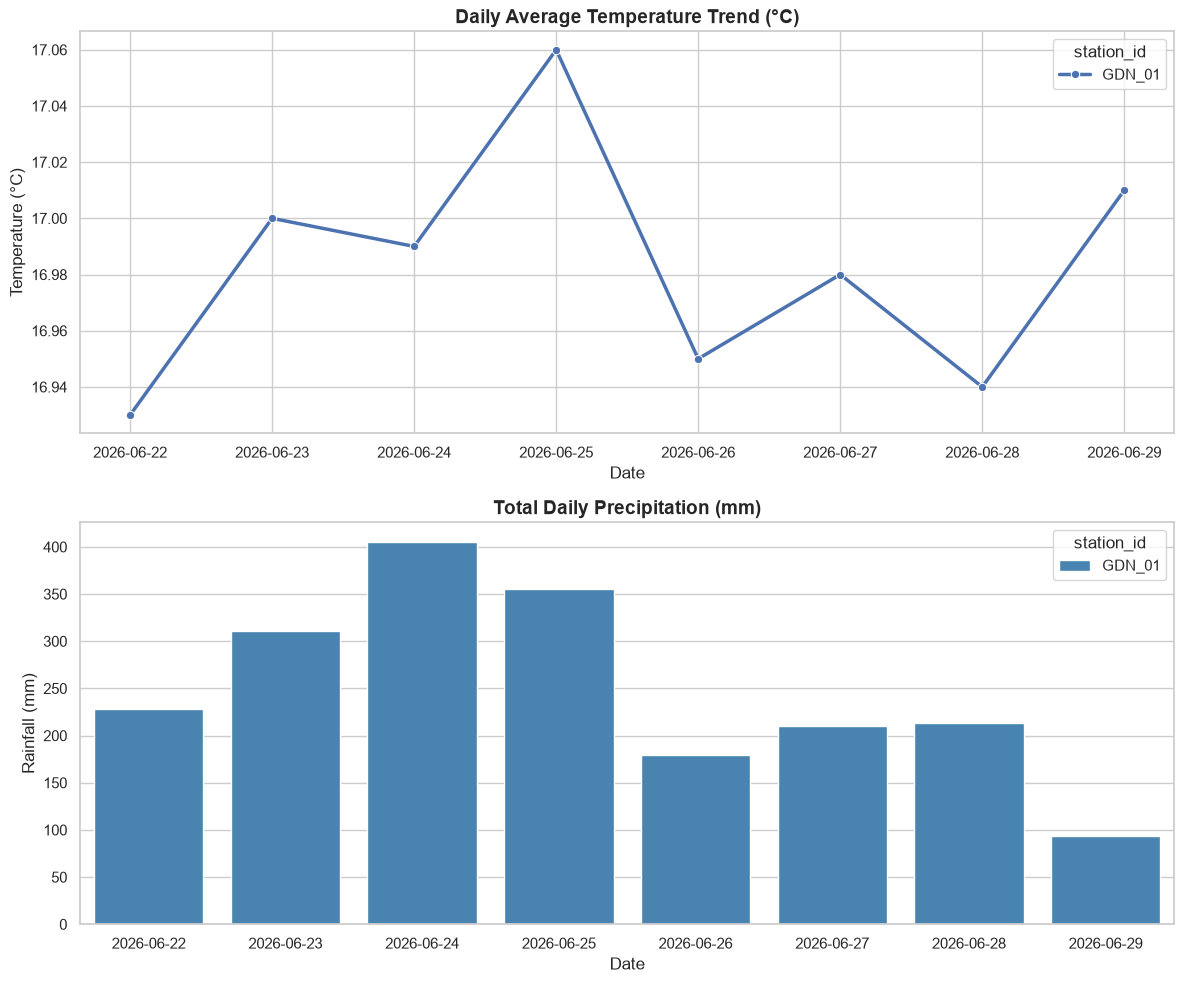

In [5]:
sns.set_theme(style="whitegrid")

if gold_data is not None and not gold_data.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    sns.lineplot(data=gold_data, x='measurement_date', y='avg_temperature', hue='station_id', 
                 marker='o', ax=axes[0], linewidth=2.5)
    axes[0].set_title('Daily Average Temperature Trend (°C)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Temperature (°C)')
    axes[0].set_xlabel('Date')
    
    sns.barplot(data=gold_data, x='measurement_date', y='total_rain_mm', hue='station_id', 
                ax=axes[1], palette="Blues_d")
    axes[1].set_title('Total Daily Precipitation (mm)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Rainfall (mm)')
    axes[1].set_xlabel('Date')
    
    plt.tight_layout()
    plt.show()

## Step 5: SQL Queries (Anomaly Detection)

In [6]:
anomaly_query = """
    SELECT 
        station_id, 
        measurement_date, 
        max_temperature, 
        total_rain_mm 
    FROM gold_data 
    WHERE max_temperature > 20.0
    ORDER BY max_temperature DESC;
"""

print("--- EXECUTING QUERY (ANOMALY REPORT) ---")
print(anomaly_query)

if gold_data is not None and not gold_data.empty:
    # Native Pandas equivalent of the SQL query above
    anomalies_df = gold_data[gold_data['max_temperature'] > 20.0].copy()
    
    if anomalies_df.empty:
        print("\nNo anomalies: No days recorded with a maximum temperature above 20°C.")
    else:
        # Selecting specific columns and sorting descending
        anomalies_df = anomalies_df[['station_id', 'measurement_date', 'max_temperature', 'total_rain_mm']]
        anomalies_df = anomalies_df.sort_values(by='max_temperature', ascending=False).reset_index(drop=True)
        
        print("\nDetected anomalies:")
        display(anomalies_df)

--- EXECUTING QUERY (ANOMALY REPORT) ---

    SELECT 
        station_id, 
        measurement_date, 
        max_temperature, 
        total_rain_mm 
    FROM gold_data 
    WHERE max_temperature > 20.0
    ORDER BY max_temperature DESC;


Detected anomalies:


,station_id,measurement_date,max_temperature,total_rain_mm
0,GDN_01,2026-06-25,21.00,355.62
1,GDN_01,2026-06-24,21.00,405.57
2,GDN_01,2026-06-23,20.99,310.48
3,GDN_01,2026-06-28,20.99,213.15
4,GDN_01,2026-06-27,20.98,210.26
5,GDN_01,2026-06-26,20.97,179.55
6,GDN_01,2026-06-29,20.97,93.91
7,GDN_01,2026-06-22,20.96,228.20
